# Sarcasm Detection — Text Cleaning & Preprocessing

Clean the raw text (lowercase, strip URLs / punctuation / digits, remove stopwords, apply Porter stemming) and save a tidy `clean_text` + `label` dataset for modeling.

## 1. Imports & Load Raw Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
from utils import load_data, clean_text
sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = load_data()
print('Raw shape:', df.shape)
df.head()

Raw shape: (28619, 2)


,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


## 2. Handle Missing / Duplicate Rows

In [3]:
print('Missing:', df.isnull().sum().sum())
print('Duplicates:', df.duplicated().sum())
df = df.dropna(subset=['headline', 'is_sarcastic']).drop_duplicates().reset_index(drop=True)
print('After cleanup:', df.shape)

Missing: 0
Duplicates: 116
After cleanup: (28503, 2)


## 3. Apply Text Cleaning

In [4]:
# clean_text: lowercase, strip urls/html/punctuation/digits, remove stopwords, Porter-stem
print('Example BEFORE:'); print(repr(df['headline'].iloc[0][:300]))
df['clean_text'] = df['headline'].astype(str).apply(clean_text)
print('\nExample AFTER:'); print(repr(df['clean_text'].iloc[0][:300]))

Example BEFORE:
'thirtysomething scientists unveil doomsday clock of hair loss'



Example AFTER:
'thirtysometh scientist unveil doomsday clock hair loss'


## 4. Drop Rows That Became Empty After Cleaning

In [5]:
before = len(df)
df = df[df['clean_text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f'Dropped {before - len(df)} rows that were empty after cleaning')
print('Remaining:', len(df))

Dropped 2 rows that were empty after cleaning
Remaining: 28501


## 5. Cleaned Text Length Comparison

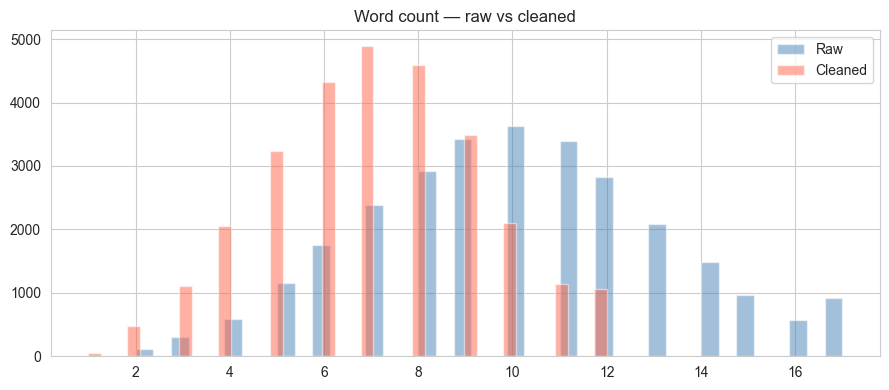

Mean words raw : 10.1
Mean words clean: 7.2


In [6]:
df['raw_words'] = df['headline'].astype(str).str.split().str.len()
df['clean_words'] = df['clean_text'].str.split().str.len()
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(df['raw_words'].clip(upper=df['raw_words'].quantile(0.97)), bins=40, alpha=0.5, label='Raw', color='steelblue')
ax.hist(df['clean_words'].clip(upper=df['clean_words'].quantile(0.97)), bins=40, alpha=0.5, label='Cleaned', color='tomato')
ax.set_title('Word count — raw vs cleaned'); ax.legend()
plt.tight_layout(); plt.show()
print('Mean words raw :', round(df['raw_words'].mean(), 1))
print('Mean words clean:', round(df['clean_words'].mean(), 1))

## 6. Encode Label

In [7]:
# is_sarcastic is already 0/1
df['label'] = df['is_sarcastic'].astype(int)
label_mapping = {0: 'not_sarcastic', 1: 'sarcastic'}
print('Label mapping:', label_mapping)

Label mapping: {0: 'not_sarcastic', 1: 'sarcastic'}


## 7. Save Cleaned Dataset

In [8]:
out = df[['clean_text', 'label']].copy()
out.to_csv('data/sarcasm_cleaned.csv', index=False)
print('Saved -> data/sarcasm_cleaned.csv', out.shape)
out.head()

Saved -> data/sarcasm_cleaned.csv (28501, 2)


,clean_text,label
0,thirtysometh scientist unveil doomsday clock h...,1
1,dem rep total nail congress fall short gender ...,0
2,eat veggi delici differ recip,0
3,inclement weather prevent liar get work,1
4,mother come pretti close use word stream corre...,1
